In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-churn/customer_churn.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/kaggle/input/customer-churn/customer_churn.csv")
df.sample(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
7613,7622.0,59.0,Female,36.0,26.0,7.0,7.0,Basic,Annual,863.0,20.0,1.0
191832,196643.0,38.0,Male,59.0,19.0,1.0,20.0,Premium,Quarterly,517.0,20.0,0.0
73104,74902.0,18.0,Female,29.0,30.0,8.0,20.0,Premium,Monthly,713.0,2.0,1.0
17247,17256.0,52.0,Female,12.0,12.0,7.0,1.0,Basic,Quarterly,850.0,25.0,1.0
190458,195269.0,21.0,Male,3.0,24.0,7.0,11.0,Premium,Annual,549.0,28.0,1.0


In [4]:
df.shape

(440833, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [6]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [7]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [8]:
df['Churn'].value_counts() 
# almost balanced

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

In [9]:
# drop customer id
df=df.iloc[:,1:12]

In [10]:
for col in df:
    print(col,df[col].nunique())

Age 48
Gender 2
Tenure 60
Usage Frequency 30
Support Calls 11
Payment Delay 31
Subscription Type 3
Contract Length 3
Total Spend 68363
Last Interaction 30
Churn 2


In [11]:
numerical_cols=['Age','Tenure','Usage Frequency','Support Calls','Payment Delay','Total Spend','Last Interaction']
categorical_cols=['Gender','Contract Length','Subscription Type']


In [12]:
df=df.dropna()
df.isnull().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [13]:

df.duplicated().sum()

np.int64(0)

In [14]:
df.info()  # data types are correct

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                440832 non-null  float64
 1   Gender             440832 non-null  object 
 2   Tenure             440832 non-null  float64
 3   Usage Frequency    440832 non-null  float64
 4   Support Calls      440832 non-null  float64
 5   Payment Delay      440832 non-null  float64
 6   Subscription Type  440832 non-null  object 
 7   Contract Length    440832 non-null  object 
 8   Total Spend        440832 non-null  float64
 9   Last Interaction   440832 non-null  float64
 10  Churn              440832 non-null  float64
dtypes: float64(8), object(3)
memory usage: 40.4+ MB


## BASIC EDA

In [15]:
X = df.drop(columns='Churn')
y = df['Churn']


In [16]:
y

0         1.0
1         1.0
2         1.0
3         1.0
4         1.0
         ... 
440828    0.0
440829    0.0
440830    0.0
440831    0.0
440832    0.0
Name: Churn, Length: 440832, dtype: float64

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [18]:
y_test

30086     1.0
368225    0.0
146939    1.0
368276    0.0
153765    1.0
         ... 
170911    1.0
286322    0.0
399598    0.0
419238    0.0
285860    0.0
Name: Churn, Length: 88167, dtype: float64

In [19]:
print(X_train.shape)
print(X_test.shape)

(352665, 10)
(88167, 10)


In [20]:
def plot_histogram(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.histplot(df[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  # calculate the mean and median values for the columns
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  # add vertical lines for mean and median
  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")

  plt.legend()

  plt.show()

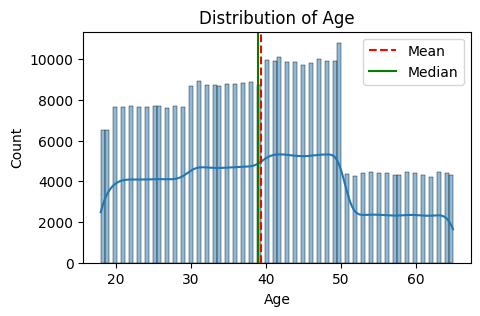

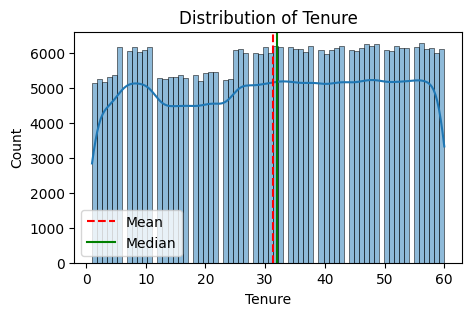

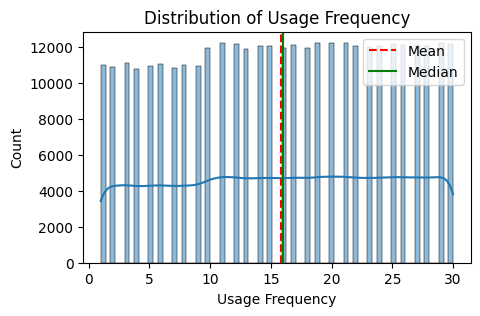

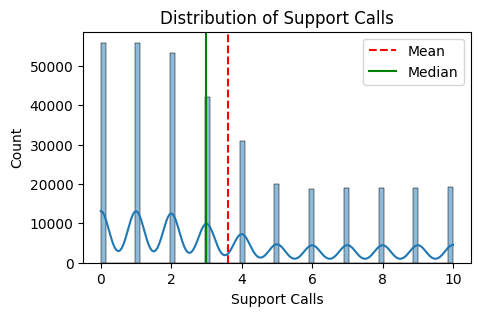

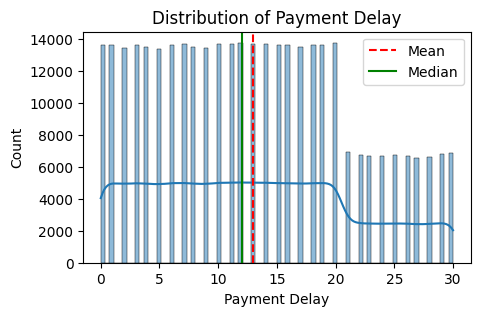

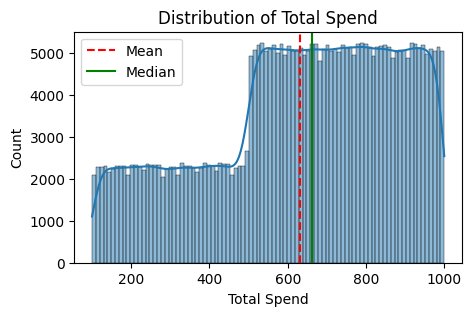

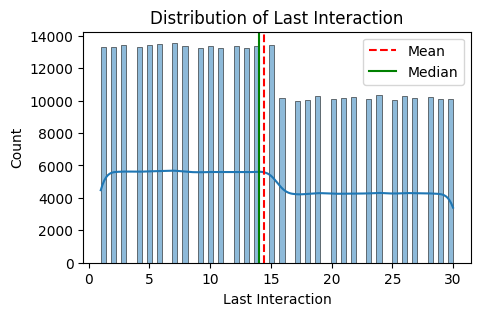

In [21]:
for col in numerical_cols:
    plot_histogram(X_train,col)
    

In [22]:
def plot_boxplot(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.boxplot(y=df[column_name])
  plt.title(f"Box Plot of {column_name}")
  plt.ylabel(column_name)
  plt.show


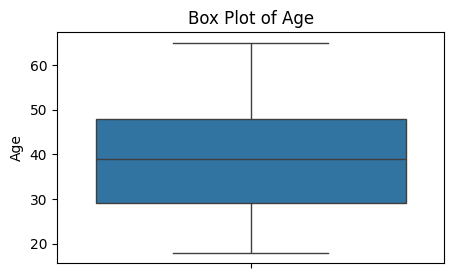

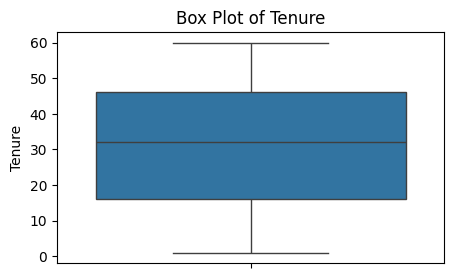

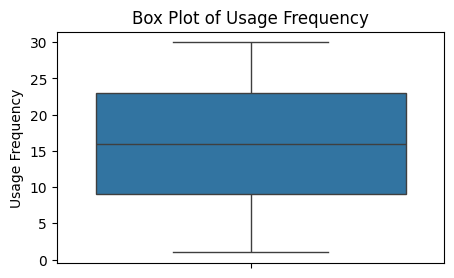

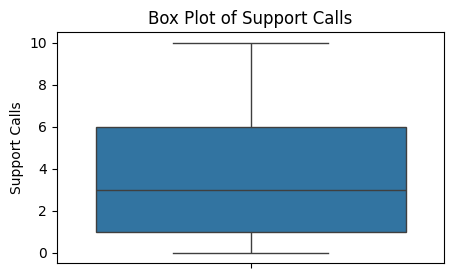

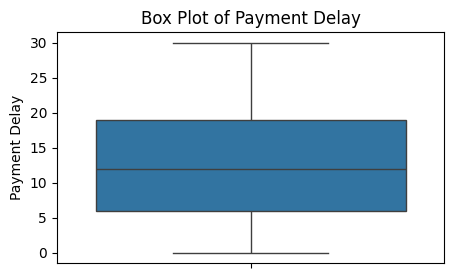

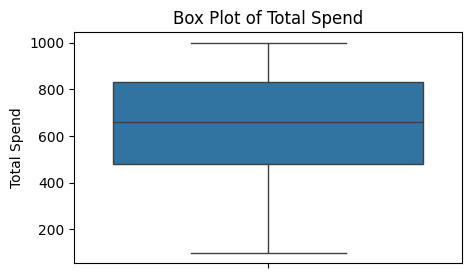

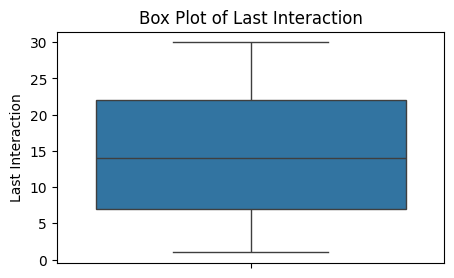

In [23]:
for col in numerical_cols:
    plot_boxplot(X_train,col)

In [24]:
for col in numerical_cols:
     print(f"skew of {col}:",X_train[col].skew())

skew of Age: 0.1607153121224291
skew of Tenure: -0.0609614477501092
skew of Usage Frequency: -0.046627466300520844
skew of Support Calls: 0.6665261211438124
skew of Payment Delay: 0.266549999336623
skew of Total Spend: -0.4572345850753074
skew of Last Interaction: 0.1774922051648709


In [25]:
# no need of normalization
# no outliers

In [26]:
temp_numerical=df.iloc[:,[0,2,3,4,5,8,9,10]]

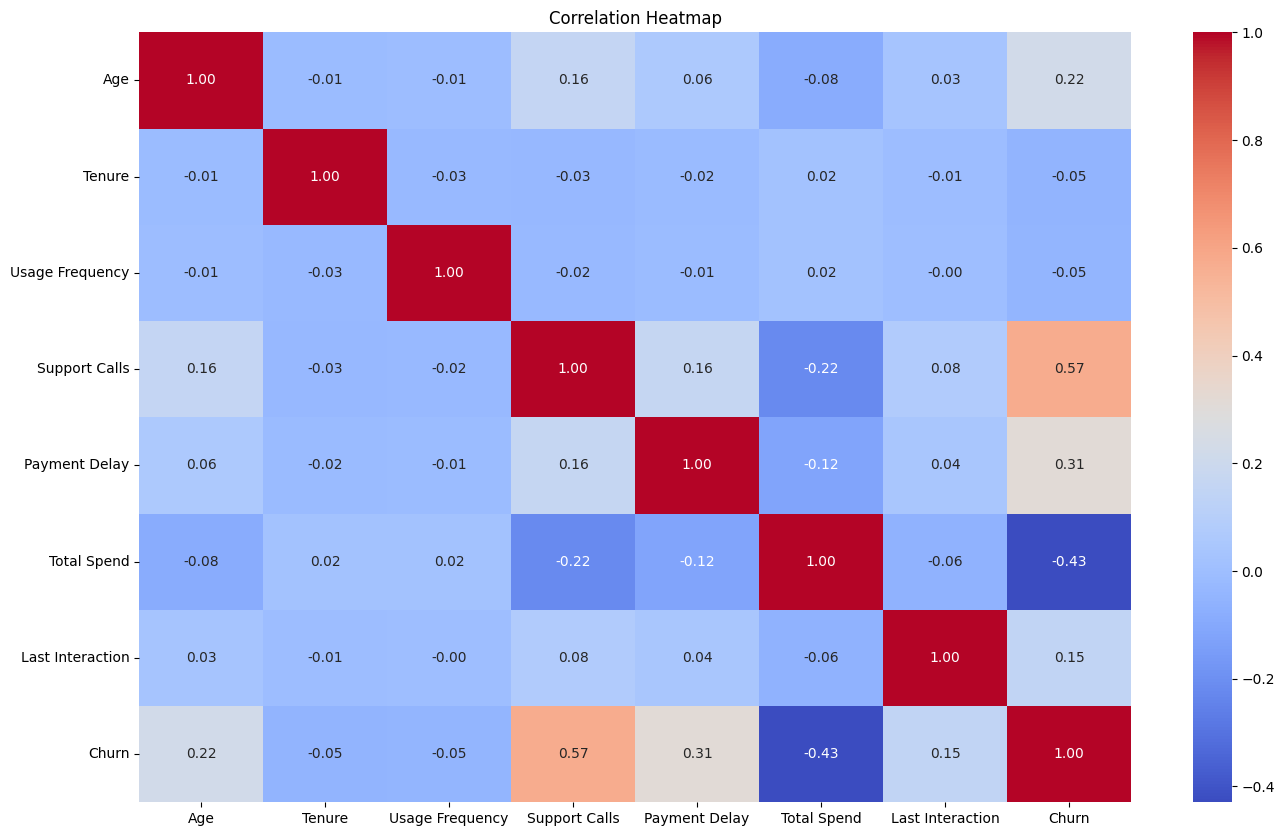

In [27]:
plt.figure(figsize=(16, 10))
sns.heatmap(temp_numerical.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [28]:
# no collinearity > 0.7 for input columns

In [29]:
X_train=X_train.drop(['Support Calls'],axis=1)
X_test=X_test.drop(['Support Calls'],axis=1)

In [30]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 352665 entries, 318331 to 70108
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                352665 non-null  float64
 1   Gender             352665 non-null  object 
 2   Tenure             352665 non-null  float64
 3   Usage Frequency    352665 non-null  float64
 4   Payment Delay      352665 non-null  float64
 5   Subscription Type  352665 non-null  object 
 6   Contract Length    352665 non-null  object 
 7   Total Spend        352665 non-null  float64
 8   Last Interaction   352665 non-null  float64
dtypes: float64(6), object(3)
memory usage: 26.9+ MB


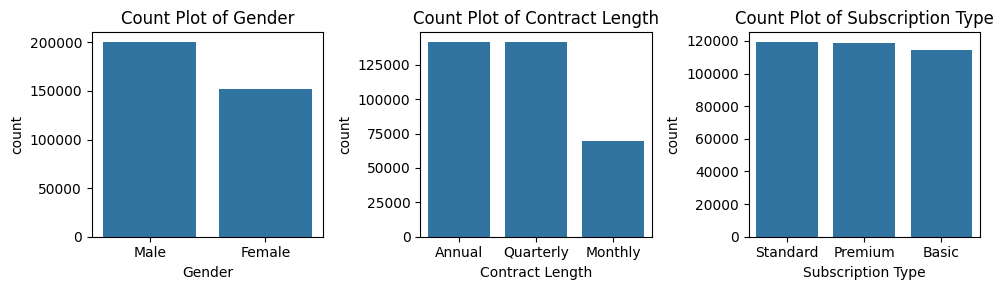

In [31]:
plt.figure(figsize=(10, 3))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=X_train[col])
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

In [39]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
trf1 = ColumnTransformer([
    ('ohe_encoding', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [1]),
    ('ordinal_encoding', OrdinalEncoder(), [5,6]),
     ],remainder='passthrough')

In [40]:
from sklearn.preprocessing import MinMaxScaler

trf2= ColumnTransformer([
    # Min-Max Scaling (0 to 1)
    ('minmax_scale', MinMaxScaler(), [0, 1,2,3,4,5,6,7,8]),

], remainder='passthrough')

In [41]:
# SVM
from sklearn.svm import SVC
trf5a= SVC(probability=True, random_state=42)

# Logistic Regression
from sklearn.linear_model import LogisticRegression
trf5b = LogisticRegression(max_iter=1000, random_state=42)

# Naive Bayes
from sklearn.naive_bayes import GaussianNB
trf5c = GaussianNB()

# Random Forest
from sklearn.ensemble import RandomForestClassifier
trf5d = RandomForestClassifier(random_state=42)

# XGBoost
from xgboost import XGBClassifier
trf5e= XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

In [42]:
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE


pipe1 = make_pipeline(
    trf1,
    trf2,
    trf5e  # classifier : xgboost
)

In [43]:
print(y_train)

318331    0.0
429062    0.0
60074     1.0
12759     1.0
357321    0.0
         ... 
154141    1.0
39618     1.0
395143    0.0
116290    1.0
70108     1.0
Name: Churn, Length: 352665, dtype: float64


In [44]:
pipe1.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:18:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe_encoding',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1]),
                                                 ('ordinal_encoding',
                                                  OrdinalEncoder(), [5, 6])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('minmax_scale',
                                                  MinMaxScaler(),
                                                  [0, 1, 2, 3, 4, 5, 6, 7,
                                                   8...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [45]:
pipe2 = make_pipeline(
    trf1,
    trf2,
    trf5d  # classifier : randomforest
)

In [46]:
pipe2.fit(X_train,y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe_encoding',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1]),
                                                 ('ordinal_encoding',
                                                  OrdinalEncoder(), [5, 6])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('minmax_scale',
                                                  MinMaxScaler(),
                                                  [0, 1, 2, 3, 4, 5, 6, 7,
                                                   8])])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [47]:
pipe3 = make_pipeline(
    trf1,
    trf2,
    trf5b  # classifier : LR
)

In [48]:
pipe3.fit(X_train,y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe_encoding',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1]),
                                                 ('ordinal_encoding',
                                                  OrdinalEncoder(), [5, 6])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('minmax_scale',
                                                  MinMaxScaler(),
                                                  [0, 1, 2, 3, 4, 5, 6, 7,
                                                   8])])),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [49]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
y_pred1 = pipe1.predict(X_test)

print(classification_report(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))

              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95     38167
         1.0       1.00      0.92      0.96     50000

    accuracy                           0.95     88167
   macro avg       0.95      0.96      0.95     88167
weighted avg       0.96      0.95      0.96     88167

[[38165     2]
 [ 3978 46022]]


In [50]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
y_pred2 = pipe2.predict(X_test)

print(classification_report(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))

              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95     38167
         1.0       1.00      0.92      0.96     50000

    accuracy                           0.96     88167
   macro avg       0.95      0.96      0.95     88167
weighted avg       0.96      0.96      0.96     88167

[[38156    11]
 [ 3955 46045]]


In [51]:
y_pred3 = pipe3.predict(X_test)

print(classification_report(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))

              precision    recall  f1-score   support

         0.0       0.71      0.71      0.71     38167
         1.0       0.78      0.78      0.78     50000

    accuracy                           0.75     88167
   macro avg       0.75      0.75      0.75     88167
weighted avg       0.75      0.75      0.75     88167

[[27072 11095]
 [10802 39198]]


In [52]:
import pickle

In [53]:
model_data = {"model": pipe2, "features_names": X_train.columns.tolist()}
# this is a dictionary


with open("churn_model.pkl", "wb") as f:
  pickle.dump(model_data, f)

In [54]:
# load the saved model and the feature names

with open("churn_model.pkl", "rb") as f:
  model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_names"]

In [55]:
print(loaded_model)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe_encoding',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1]),
                                                 ('ordinal_encoding',
                                                  OrdinalEncoder(), [5, 6])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('minmax_scale',
                                                  MinMaxScaler(),
                                                  [0, 1, 2, 3, 4, 5, 6, 7,
                                                   8])])),
                ('randomforestclassifier',
                 RandomForestClassifier(rand

In [56]:
print(feature_names)

['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']
